<a href="https://colab.research.google.com/github/fartech00/TAFU_Suniy-intellekt-asoslari/blob/main/TAFU_coding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

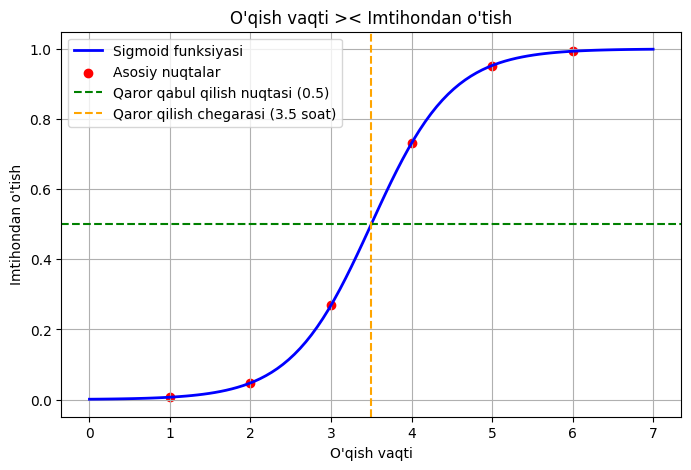

In [ ]:
# SIGMOID FUNKSIYASIGA OID MISOL

import numpy as np
import matplotlib.pyplot as plt


def sigmoid(z):
    return 1 / (1 + np.exp(-z))
w1 = 2     # weight
b = -7     # bias

hours = np.linspace(0, 7, 100)
z = w1 * hours + b
prob = sigmoid(z)

#Plot
plt.figure(figsize=(8,5))
plt.plot(hours, prob, color='blue', linewidth=2, label='Sigmoid funksiyasi')
plt.scatter([1,2,3,4,5,6], sigmoid(w1*np.array([1,2,3,4,5,6])+b),
            color='red', label='Asosiy nuqtalar')
plt.axhline(0.5, color='green', linestyle='--', label='Qaror qabul qilish nuqtasi (0.5)')
plt.axvline(3.5, color='orange', linestyle='--', label='Qaror qilish chegarasi (3.5 soat)')

plt.title("O'qish vaqti >< Imtihondan o'tish")
plt.xlabel("O'qish vaqti")
plt.ylabel("Imtihondan o'tish")
plt.legend()
plt.grid(True)
plt.show()


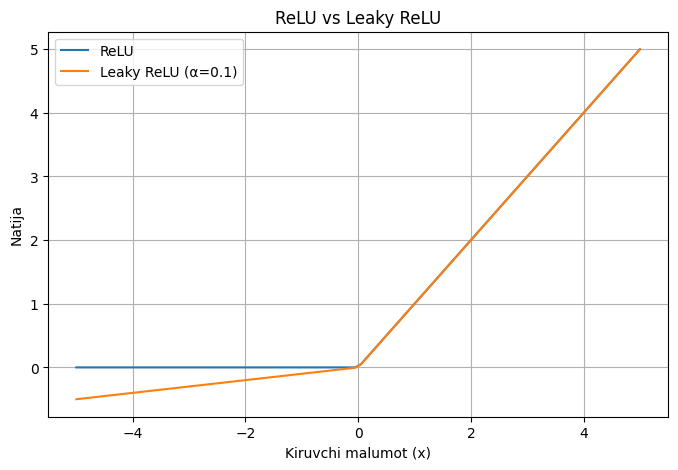

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

x = torch.linspace(-5, 5, 100)
y_relu = F.relu(x)
y_leaky = F.leaky_relu(x, negative_slope=0.1)

plt.figure(figsize=(8,5))
plt.plot(x.numpy(), y_relu.numpy(), label="ReLU")
plt.plot(x.numpy(), y_leaky.numpy(), label="Leaky ReLU (α=0.1)")
plt.title("ReLU vs Leaky ReLU")
plt.xlabel("Kiruvchi malumot (x)")
plt.ylabel("Natija")
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
import torch.nn as nn

model = nn.Sequential(
    nn.Conv2d(3, 32, kernel_size=3, padding=1),
    nn.LeakyReLU(0.1),
    nn.MaxPool2d(2, 2),
    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.LeakyReLU(0.1),
    nn.MaxPool2d(2, 2),
    nn.Flatten(),
    nn.Linear(64 * 8 * 8, 10),
    nn.Softmax(dim=1)
)


**Takrorlash**

> O'tilgan darsga oid savollarga javob bering



In [ ]:
!pip install gradio pandas

## **KNN:** algoritmi bo'yicha klassifikatsiyalash

In [33]:
https://remix-deep-learning-masterclass-knn-edition-389613205060.asia-southeast1.run.app

SyntaxError: invalid decimal literal (1965067107.py, line 1)

In [13]:
# ================================================================
# CELL 1: ZARUR KUTUBXONALARNI IMPORT QILISH
# ================================================================

import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

In [14]:
# ================================================================
# CELL 2: MA'LUMOTLARNI YUKLASH
# ================================================================

iris = load_iris()
X = iris.data
y = iris.target

print(f"""
✓ Iris ma'lumotlar to'plami yukland!

📊 Ma'lumotlar haqida:
  - Jami namunalar: {X.shape[0]} ta
  - Xususiyatlar: {X.shape[1]} ta
  - Klasslar soni: {len(np.unique(y))} ta

🌸 Gulining turlari:
  {', '.join(iris.target_names)}

📌 Xususiyatlar:
  {chr(10).join('  ' + name for name in iris.feature_names)}
""")


✓ Iris ma'lumotlar to'plami yukland!
  
📊 Ma'lumotlar haqida:
  - Jami namunalar: 150 ta
  - Xususiyatlar: 4 ta
  - Klasslar soni: 3 ta
  
🌸 Gulining turlari:
  setosa, versicolor, virginica
  
📌 Xususiyatlar:
    sepal length (cm)
  sepal width (cm)
  petal length (cm)
  petal width (cm)



In [17]:
# ================================================================
# CELL 3: MA'LUMOTLARNI TREYN VA TEST QISMLARGA BO'LISH
# ================================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"""
✓ Ma'lumotlar muvaffaqiyatli bo'lindi!

📊 Bo'linish natijasi:
  - Treynlash ma'lumotlari: {X_train.shape[0]} ta namuna
  - Test ma'lumotlari: {X_test.shape[0]} ta namuna
  - Foiz: {X_train.shape[0]/len(X)*100:.0f}% treyn, {X_test.shape[0]/len(X)*100:.0f}% test
""")


✓ Ma'lumotlar muvaffaqiyatli bo'lindi!

📊 Bo'linish natijasi:
  - Treynlash ma'lumotlari: 120 ta namuna
  - Test ma'lumotlari: 30 ta namuna
  - Foiz: 80% treyn, 20% test



In [18]:
# ================================================================
# CELL 4: XUSUSIYATLARNI NORMALLASH
# ================================================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"""
✓ Xususiyatlar normallashdi!

📊 Normallash haqida:
  Bu qadam KNN algoritmi uchun muhim, chunki:
  - Bosh xususiyatlar boshqalarning ta'sirini kamaytiradigan usul
  - Hamma xususiyatlar teng muhimlikka ega bo'ladi
  - Modelning aniqligini yaxshilaydi

🔢 Misollar:
  Normallashdan oldin: {X_train[0][:2]}
  Normallashdan keyin: {X_train_scaled[0][:2]}
""")



✓ Xususiyatlar normallashdi!

📊 Normallash haqida:
  Bu qadam KNN algoritmi uchun muhim, chunki:
  - Bosh xususiyatlar boshqalarning ta'sirini kamaytiradigan usul
  - Hamma xususiyatlar teng muhimlikka ega bo'ladi
  - Modelning aniqligini yaxshilaydi

🔢 Misollar:
  Normallashdan oldin: [4.6 3.6]
  Normallashdan keyin: [-1.47393679  1.20365799]



In [20]:
# ================================================================
# CELL 5: KNN MODELINI YARATISH VA O'RGATISH
# ================================================================

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, y_train)

print(f"""
✓ KNN modeli muvaffaqiyatli o'rgatildi!

📚 O'rgatish haqida:
  - Algoritm: K-Nearest Neighbors
  - K qiymati: 3 (eng yaqin 3 ta qo'shni ko'rib chiqamiz)
  - O'rgatish namunalari: {X_train_scaled.shape[0]} ta
  - Metrika: Evklidean masofasi (default)

💡 K = 3 ning ma'nosi:
  Yangi namunani sinflendirish uchun eng yaqin 3 ta
  o'rgatish namunasiga qaraydi va ko'p bilan uchragan
  klassni bashorat sifatida tanlaydi.
""")


✓ KNN modeli muvaffaqiyatli o'rgatildi!

📚 O'rgatish haqida:
  - Algoritm: K-Nearest Neighbors
  - K qiymati: 3 (eng yaqin 3 ta qo'shni ko'rib chiqamiz)
  - O'rgatish namunalari: 120 ta
  - Metrika: Evklidean masofasi (default)

💡 K = 3 ning ma'nosi:
  Yangi namunani sinflendirish uchun eng yaqin 3 ta 
  o'rgatish namunasiga qaraydi va ko'p bilan uchragan 
  klassni bashorat sifatida tanlaydi.



In [21]:
# ================================================================
# CELL 6: TEST MA'LUMOTLARI UCHUN BASHORAT QILISH
# ================================================================

y_pred = knn.predict(X_test_scaled)

print(f"""
✓ Test ma'lumotlari uchun bashorat qilindi!

📊 Bashorat natijalari (Birinchi 10 ta):
""")

for i in range(min(10, len(y_test))):
    actual_name = iris.target_names[y_test[i]]
    predicted_name = iris.target_names[y_pred[i]]
    match = "✓" if y_test[i] == y_pred[i] else "✗"
    print(f"  {match} Test {i+1}: Haqiqiy={actual_name:12} | Bashorat={predicted_name:12}")



✓ Test ma'lumotlari uchun bashorat qilindi!

📊 Bashorat natijalari (Birinchi 10 ta):

  ✓ Test 1: Haqiqiy=versicolor   | Bashorat=versicolor  
  ✓ Test 2: Haqiqiy=setosa       | Bashorat=setosa      
  ✓ Test 3: Haqiqiy=virginica    | Bashorat=virginica   
  ✓ Test 4: Haqiqiy=versicolor   | Bashorat=versicolor  
  ✓ Test 5: Haqiqiy=versicolor   | Bashorat=versicolor  
  ✓ Test 6: Haqiqiy=setosa       | Bashorat=setosa      
  ✓ Test 7: Haqiqiy=versicolor   | Bashorat=versicolor  
  ✓ Test 8: Haqiqiy=virginica    | Bashorat=virginica   
  ✓ Test 9: Haqiqiy=versicolor   | Bashorat=versicolor  
  ✓ Test 10: Haqiqiy=versicolor   | Bashorat=versicolor  


In [23]:

# ================================================================
# CELL 7: NATIJALARNI BAHOLASH
# ================================================================

accuracy = accuracy_score(y_test, y_pred)

print(f"""
✓ Natijalar baholandi!

🎯 ANIQLIK (Accuracy):
  {accuracy:.1%}

  Demak, 100 ta testdan {int(accuracy*100)} tasi to'g'ri tasnif qilindi!

📋 HAR BIR KLASS UCHUN BATAFSIL NATIJALAR:
""")

# Classification report
report = classification_report(y_test, y_pred,
                               target_names=iris.target_names,
                               output_dict=True)

for class_name in iris.target_names:
    precision = report[class_name]['precision']
    recall = report[class_name]['recall']
    f1 = report[class_name]['f1-score']
    support = int(report[class_name]['support'])

    print(f"""
  {class_name.upper()}:
    - Precision (Aniqlik): {precision:.1%}
    - Recall (Eslash): {recall:.1%}
    - F1-Score: {f1:.3f}
    - Namunalar soni: {support} ta
""")


✓ Natijalar baholandi!

🎯 ANIQLIK (Accuracy):
  100.0%
  
  Demak, 100 ta testdan 100 tasi to'g'ri tasnif qilindi!

📋 HAR BIR KLASS UCHUN BATAFSIL NATIJALAR:


  SETOSA:
    - Precision (Aniqlik): 100.0%
    - Recall (Eslash): 100.0%
    - F1-Score: 1.000
    - Namunalar soni: 10 ta


  VERSICOLOR:
    - Precision (Aniqlik): 100.0%
    - Recall (Eslash): 100.0%
    - F1-Score: 1.000
    - Namunalar soni: 9 ta


  VIRGINICA:
    - Precision (Aniqlik): 100.0%
    - Recall (Eslash): 100.0%
    - F1-Score: 1.000
    - Namunalar soni: 11 ta



In [24]:

# ================================================================
# CELL 8: ENG YAXSHI K QIYMATINI TOPISH
# ================================================================

accuracies = []
k_values = range(1, 16)

print(f"""
Turli K qiymatlariga sinovdan o'tkazilmoqda...
""")

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_scaled, y_train)
    y_pred_temp = knn_temp.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred_temp)
    accuracies.append(acc)

best_k = k_values[np.argmax(accuracies)]
best_accuracy = max(accuracies)

print(f"\n  K qiymati    Aniqlik")
print(f"  " + "-" * 30)
for k, acc in zip(k_values, accuracies):
    marker = " ← ENG YAXSHI" if k == best_k else ""
    print(f"    k={k:2d}         {acc:.1%}{marker}")

print(f"""
✓ ENG YAXSHI K QIYMATI TOPILDI!

🎯 NATIIJA:
  K = {best_k}
  Aniqlik = {best_accuracy:.1%}

💡 NASIHALAR:
  - K = 1: Overfitting xavfi (model hammasi yodlab qoladi)
  - K = √n: Umumiy qoida (n = namunalar soni)
  - K = 3-7: Ko'pincha yaxshi natija beradi
""")


Turli K qiymatlariga sinovdan o'tkazilmoqda...


  K qiymati    Aniqlik
  ------------------------------
    k= 1         100.0% ← ENG YAXSHI
    k= 2         100.0%
    k= 3         100.0%
    k= 4         100.0%
    k= 5         100.0%
    k= 6         100.0%
    k= 7         100.0%
    k= 8         100.0%
    k= 9         100.0%
    k=10         100.0%
    k=11         100.0%
    k=12         100.0%
    k=13         100.0%
    k=14         100.0%
    k=15         100.0%

✓ ENG YAXSHI K QIYMATI TOPILDI!

🎯 NATIIJA:
  K = 1
  Aniqlik = 100.0%
  
💡 NASIHALAR:
  - K = 1: Overfitting xavfi (model hammasi yodlab qoladi)
  - K = √n: Umumiy qoida (n = namunalar soni)
  - K = 3-7: Ko'pincha yaxshi natija beradi



In [26]:

# ================================================================
# CELL 9: YANGI NAMUNA UCHUN BASHORAT
# ================================================================


# Yangi gul xususiyatlari
new_flower = np.array([[5.5, 3.2, 4.5, 1.3]])
new_flower_scaled = scaler.transform(new_flower)

prediction = knn.predict(new_flower_scaled)[0]
probabilities = knn.predict_proba(new_flower_scaled)[0]

print(f"""
✓ Yangi Iris guli uchun bashorat qilindi!

🌸 YANGI GULNING XUSUSIYATLARI:
  - Sepal uzunligi: 5.5 cm
  - Sepal kengligi: 3.2 cm
  - Petal uzunligi: 4.5 cm
  - Petal kengligi: 1.3 cm

🎯 BASHORAT:
  Turi: {iris.target_names[prediction]}

📊 EHTIMOLLIKLAR:
""")

for i, prob in enumerate(probabilities):
    bar = "█" * int(prob * 20) + "░" * (20 - int(prob * 20))
    print(f"  {iris.target_names[i]:12} {prob:.1%} [{bar}]")



✓ Yangi Iris guli uchun bashorat qilindi!

🌸 YANGI GULNING XUSUSIYATLARI:
  - Sepal uzunligi: 5.5 cm
  - Sepal kengligi: 3.2 cm
  - Petal uzunligi: 4.5 cm
  - Petal kengligi: 1.3 cm

🎯 BASHORAT:
  Turi: versicolor

📊 EHTIMOLLIKLAR:

  setosa       0.0% [░░░░░░░░░░░░░░░░░░░░]
  versicolor   100.0% [████████████████████]
  virginica    0.0% [░░░░░░░░░░░░░░░░░░░░]


In [27]:

# ================================================================
# CELL 10: CONFUZION MATRITSA
# =========================================================
cm = confusion_matrix(y_test, y_pred)

print(f"""
✓ Confuzion matritsa tayyorlandi!

📊 MATRITSA TALQINI:
  - Diagonal qiymatlar: To'g'ri tasniflanganlar
  - Diagonal tashqari qiymatlar: Noto'g'ri tasniflanganlar

📋 MATRITSA:

           {iris.target_names[0]:12} {iris.target_names[1]:12} {iris.target_names[2]:12}
""")

for i, class_name in enumerate(iris.target_names):
    print(f"  {class_name:10}", end=" ")
    for j in range(len(iris.target_names)):
        print(f"{cm[i, j]:>15}", end=" ")
    print()

print(f"""
🔍 TALQIN:
  - [0,0] = {cm[0,0]}: {iris.target_names[0]} to'g'ri
  - [1,1] = {cm[1,1]}: {iris.target_names[1]} to'g'ri
  - [2,2] = {cm[2,2]}: {iris.target_names[2]} to'g'ri
""")


✓ Confuzion matritsa tayyorlandi!

📊 MATRITSA TALQINI:
  - Diagonal qiymatlar: To'g'ri tasniflanganlar
  - Diagonal tashqari qiymatlar: Noto'g'ri tasniflanganlar

📋 MATRITSA:
  
           setosa       versicolor   virginica   

  setosa                  10               0               0 
  versicolor               0               9               0 
  virginica                0               0              11 

🔍 TALQIN:
  - [0,0] = 10: setosa to'g'ri
  - [1,1] = 9: versicolor to'g'ri
  - [2,2] = 11: virginica to'g'ri



  ✓ Test 1: Haqiqiy=setosa, Bashorat=setosa
  ✓ Test 2: Haqiqiy=virginica, Bashorat=virginica
  ✓ Test 3: Haqiqiy=versicolor, Bashorat=versicolor
  ✓ Test 4: Haqiqiy=versicolor, Bashorat=versicolor
  ✓ Test 5: Haqiqiy=setosa, Bashorat=setosa
  ✓ Test 6: Haqiqiy=versicolor, Bashorat=versicolor
  ✓ Test 7: Haqiqiy=setosa, Bashorat=setosa
  ✓ Test 8: Haqiqiy=setosa, Bashorat=setosa
  ✓ Test 9: Haqiqiy=virginica, Bashorat=virginica
  ✓ Test 10: Haqiqiy=versicolor, Bashorat=versicolor

✓ Aniqlik (Accuracy): 93.33%
📋 Aniqlikni har bir klass uchun ko'rib chiqamiz:

  setosa:
    - Precision: 1.000
    - Recall: 1.000
    - F1-Score: 1.000
  versicolor:
    - Precision: 0.833
    - Recall: 1.000
    - F1-Score: 0.909
  virginica:
    - Precision: 1.000
    - Recall: 0.800
    - F1-Score: 0.889

  k= 1: Aniqlik = 0.967
  k= 2: Aniqlik = 0.933
  k= 3: Aniqlik = 0.933
  k= 4: Aniqlik = 0.933
  k= 5: Aniqlik = 0.933
  k= 6: Aniqlik = 0.933
  k= 7: Aniqlik = 0.967
  k= 8: Aniqlik = 0.933
  k= 9: An

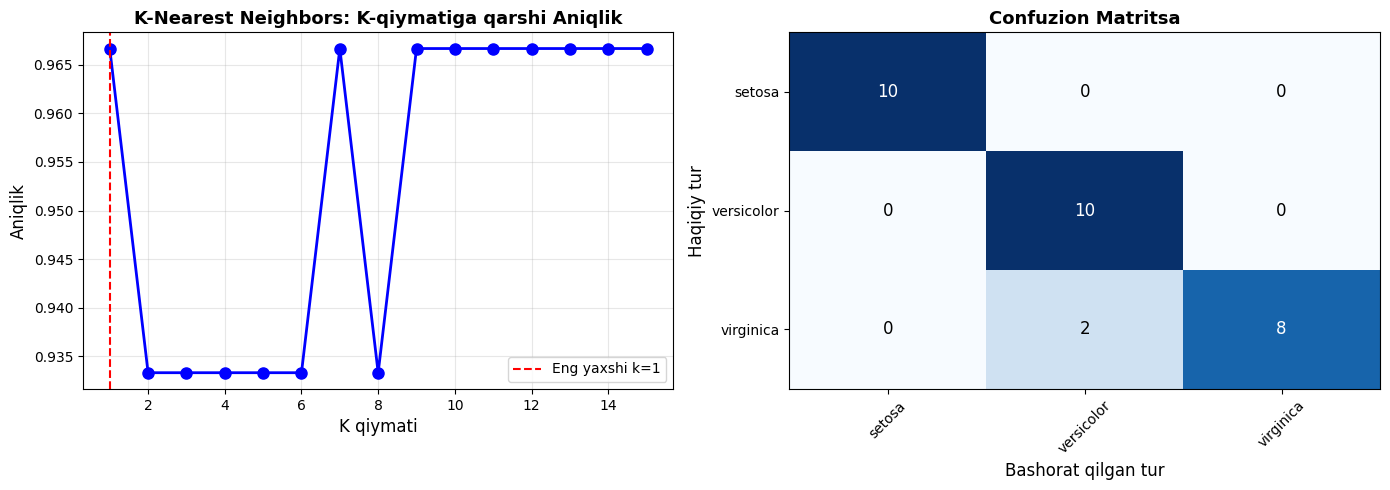

In [30]:
# ================================================================
# Qadamma-Qadamga KNN Masalalari
# ================================================================
# ================================================================
# 1-LOYIHA: IRIS GULINING TURINI ANIQLASH
# ================================================================

# Zarur kutubxonalarni import qilish
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import warnings
warnings.filterwarnings('ignore')

# Iris ma'lumot to'plamini yuklash
iris = load_iris()
X = iris.data  # Xususiyatlar (sepal uzunligi, sepal kengligi, petal uzunligi, petal kengligi)
y = iris.target  # Maqsad (0=Setosa, 1=Versicolor, 2=Virginica)

# Pandas DataFrame'ga aylantirish
df = pd.DataFrame(X, columns=iris.feature_names)
df['Turi'] = [iris.target_names[t] for t in y]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% test ma'lumotlar
    random_state=42,    # Takrorlanuvchi natijalar uchun
    stratify=y          # Har bir klassdan teng miqdorda
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# KNN modeli (k=3)
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

for i in range(10):
    actual = iris.target_names[y_test[i]]
    predicted = iris.target_names[y_pred[i]]
    status = "✓" if actual == predicted else "✗"
    print(f"  {status} Test {i+1}: Haqiqiy={actual}, Bashorat={predicted}")
print()

accuracy = accuracy_score(y_test, y_pred)
print(f"✓ Aniqlik (Accuracy): {accuracy:.2%}")

print("📋 Aniqlikni har bir klass uchun ko'rib chiqamiz:")
report = classification_report(y_test, y_pred,
                               target_names=iris.target_names,
                               output_dict=True)
print()
for class_name in iris.target_names:
    precision = report[class_name]['precision']
    recall = report[class_name]['recall']
    f1 = report[class_name]['f1-score']
    print(f"  {class_name}:")
    print(f"    - Precision: {precision:.3f}")
    print(f"    - Recall: {recall:.3f}")
    print(f"    - F1-Score: {f1:.3f}")
print()


accuracies = []
k_values = range(1, 16)

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_scaled, y_train)
    y_pred_temp = knn_temp.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred_temp)
    accuracies.append(acc)
    print(f"  k={k:2d}: Aniqlik = {acc:.3f}")

best_k = k_values[np.argmax(accuracies)]
best_accuracy = max(accuracies)
print(f"\n✓ Eng yaxshi k={best_k} (Aniqlik: {best_accuracy:.3f})")

# Yangi gul xususiyatlari (sepal uzunligi, sepal kengligi, petal uzunligi, petal kengligi)
new_flower = np.array([[5.5, 3.2, 4.5, 1.3]])
new_flower_scaled = scaler.transform(new_flower)

prediction = knn.predict(new_flower_scaled)[0]
probabilities = knn.predict_proba(new_flower_scaled)[0]

for i, prob in enumerate(probabilities):
    print(f"    {iris.target_names[i]}: {prob:.3f}")
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# K-qiymatiga qarshi aniqlik
axes[0].plot(k_values, accuracies, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(x=best_k, color='r', linestyle='--', label=f'Eng yaxshi k={best_k}')
axes[0].set_xlabel('K qiymati', fontsize=12)
axes[0].set_ylabel('Aniqlik', fontsize=12)
axes[0].set_title('K-Nearest Neighbors: K-qiymatiga qarshi Aniqlik', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Confuzion matritsa
cm = confusion_matrix(y_test, y_pred)
im = axes[1].imshow(cm, cmap='Blues', aspect='auto')
axes[1].set_xlabel('Bashorat qilgan tur', fontsize=12)
axes[1].set_ylabel('Haqiqiy tur', fontsize=12)
axes[1].set_title('Confuzion Matritsa', fontsize=13, fontweight='bold')
axes[1].set_xticks(range(len(iris.target_names)))
axes[1].set_yticks(range(len(iris.target_names)))
axes[1].set_xticklabels(iris.target_names, rotation=45)
axes[1].set_yticklabels(iris.target_names)

# Confuzion matritsa qiymatlarini yozish
for i in range(len(iris.target_names)):
    for j in range(len(iris.target_names)):
        axes[1].text(j, i, str(cm[i, j]), ha='center', va='center',
                    color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=12)

plt.tight_layout()
plt.savefig('/tmp/iris_classification.png', dpi=100, bbox_inches='tight')




✓ 200 ta uyning ma'lumotlari yaratildi!

📋 Birinchi 5 ta uyni ko'rib chiqamiz:
   Maydoni_m2  Xonalari_soni  Qurulish_yili  Vanna_xonalari_soni  Garaj_bormi  \
0  143.635030              4           2012                    2            1   
1  287.678577              3           2019                    3            1   
2  232.998485              1           1989                    1            1   
3  199.664621              4           2022                    2            1   
4   89.004660              4           2008                    3            0   

            Baho  
0  656172.536538  
1  752381.115339  
2  471471.912952  
3  597658.709321  
4  415653.925774  

📊 Ma'lumotlarning statistikasi:
       Maydoni_m2  Xonalari_soni  Qurulish_yili  Vanna_xonalari_soni  \
count  200.000000     200.000000     200.000000           200.000000   
mean   171.001558       3.035000    2001.120000             2.015000   
std     73.722858       1.440189      11.778338             0.817383   

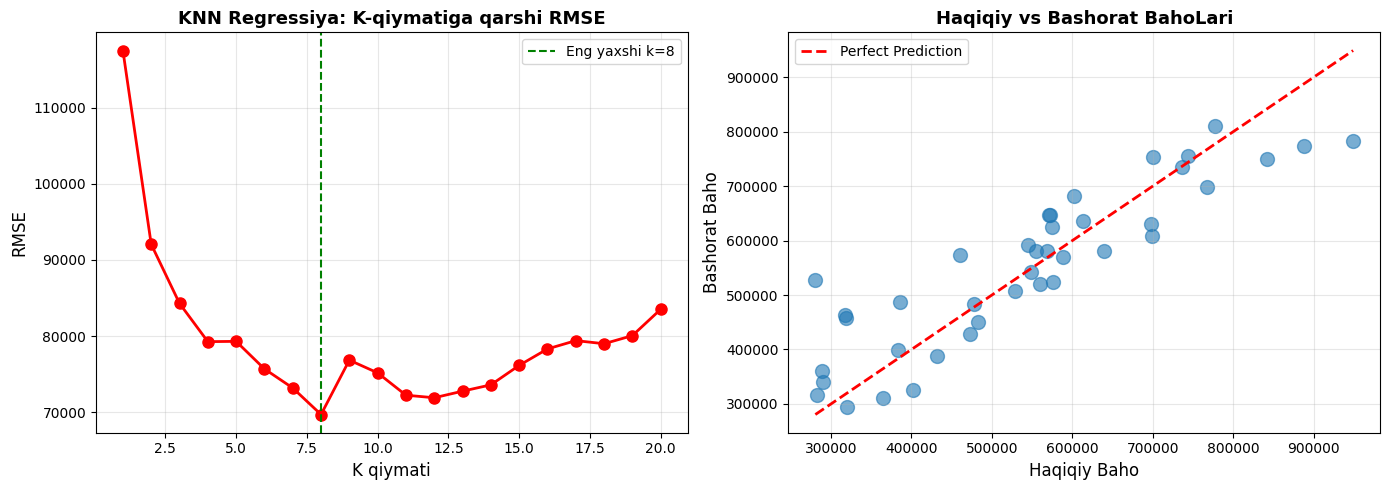

In [32]:

# ================================================================
# 2-LOYIHA: UYNING BAHOSINI BASHORAT QILISH
# ================================================================

np.random.seed(42)

# Suniy uylar ma'lumotlari
n_houses = 200
house_data = {
    'Maydoni_m2': np.random.uniform(50, 300, n_houses),
    'Xonalari_soni': np.random.randint(1, 6, n_houses),
    'Qurulish_yili': np.random.randint(1980, 2023, n_houses),
    'Vanna_xonalari_soni': np.random.randint(1, 4, n_houses),
    'Garaj_bormi': np.random.randint(0, 2, n_houses),
}

# Baho hisoblash (suniy formulasi)
house_data['Baho'] = (
    house_data['Maydoni_m2'] * 2000 +
    house_data['Xonalari_soni'] * 50000 +
    (2023 - house_data['Qurulish_yili']) * (-1000) +
    house_data['Vanna_xonalari_soni'] * 30000 +
    house_data['Garaj_bormi'] * 20000 +
    np.random.normal(0, 50000, n_houses)  # Shumdik xatolik
)

house_df = pd.DataFrame(house_data)

print(f"✓ {n_houses} ta uyning ma'lumotlari yaratildi!")
print()
print("📋 Birinchi 5 ta uyni ko'rib chiqamiz:")
print(house_df.head())
print()
print(f"📊 Ma'lumotlarning statistikasi:")
print(house_df.describe())
print()

# -------- QISM 2.2: Xususiyatlar va maqsadni ajratish --------
print("\n📊 QISM 2.2: Xususiyatlar va maqsad (Baho) ni ajratish")
print("-" * 80)

X_house = house_df[['Maydoni_m2', 'Xonalari_soni', 'Qurulish_yili', 'Vanna_xonalari_soni', 'Garaj_bormi']].values
y_house = house_df['Baho'].values

print(f"✓ Xususiyatlar va maqsad ajratildi!")
print(f"  - Xususiyatlar soni: {X_house.shape[1]}")
print(f"  - Namunalar soni: {X_house.shape[0]}")
print()

# -------- QISM 2.3: O'qitish va test bo'lish --------
print("\n📊 QISM 2.3: Ma'lumotlarni treyn va testga bo'lish")
print("-" * 80)

X_train_house, X_test_house, y_train_house, y_test_house = train_test_split(
    X_house, y_house,
    test_size=0.2,
    random_state=42
)

print(f"✓ Ma'lumotlar bo'lindi!")
print(f"  - Treynlash: {X_train_house.shape[0]} ta uy")
print(f"  - Test: {X_test_house.shape[0]} ta uy")
print()

# -------- QISM 2.4: Normallash --------
print("\n📊 QISM 2.4: Xususiyatlarni normallash")
print("-" * 80)

scaler_house = StandardScaler()
X_train_house_scaled = scaler_house.fit_transform(X_train_house)
X_test_house_scaled = scaler_house.transform(X_test_house)

print(f"✓ Xususiyatlar normallashdi!")
print()

# -------- QISM 2.5: KNN  --------
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_train_house_scaled, y_train_house)

y_pred_house = knn_reg.predict(X_test_house_scaled)

print(f"✓ KNN Regressor o'rgatildi! (k=5)")
print()

# -------- QISM 2.6: Natijalarni baholash --------
print("\n📊 QISM 2.6: Regressiya natijalarini baholash")
print("-" * 80)

mse = mean_squared_error(y_test_house, y_pred_house)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(y_test_house - y_pred_house))
r2 = r2_score(y_test_house, y_pred_house)

print(f"✓ Xatolarni hisoblandi!")
print(f"  - MSE (O'rtacha Kvadrat Xatosi): {mse:,.0f}")
print(f"  - RMSE (Ildiz O'rtacha Kvadrat Xatosi): {rmse:,.0f}")
print(f"  - MAE (O'rtacha Absolyut Xatosi): {mae:,.0f}")
print(f"  - R² Skorasi: {r2:.3f}")
print()

# -------- QISM 2.7: Bashorat misollar --------
print("\n📊 QISM 2.7: Birinchi 5 ta testdagi uy uchun bashorat")
print("-" * 80)

print(f"{'#':<3} {'Haqiqiy Baho':<15} {'Bashorat':<15} {'Xatosi':<15}")
print("-" * 50)
for i in range(5):
    actual = y_test_house[i]
    predicted = y_pred_house[i]
    error = abs(actual - predicted)
    print(f"{i+1:<3} {actual:>13,.0f} {predicted:>13,.0f} {error:>13,.0f}")
print()

# -------- QISM 2.8: Eng yaxshi K topish --------
print("\n📊 QISM 2.8: Eng yaxshi K qiymatini topish")
print("-" * 80)

k_values_house = range(1, 21)
rmse_values = []

for k in k_values_house:
    knn_temp = KNeighborsRegressor(n_neighbors=k)
    knn_temp.fit(X_train_house_scaled, y_train_house)
    y_pred_temp = knn_temp.predict(X_test_house_scaled)
    rmse_temp = np.sqrt(mean_squared_error(y_test_house, y_pred_temp))
    rmse_values.append(rmse_temp)
    if k <= 5 or k % 5 == 0:
        print(f"  k={k:2d}: RMSE = {rmse_temp:>10,.0f}")

best_k_house = k_values_house[np.argmin(rmse_values)]
best_rmse = min(rmse_values)
print(f"\n✓ Eng yaxshi k={best_k_house} (RMSE: {best_rmse:,.0f})")
print()

# -------- QISM 2.9: Yangi uy uchun bashorat --------
print("\n📊 QISM 2.9: Yangi uy uchun baho bashorat")
print("-" * 80)

# Yangi uyning xususiyatlari
new_house = np.array([[150, 3, 2010, 2, 1]])  # Maydoni, Xonalar, Yili, Vannalari, Garaj
new_house_scaled = scaler_house.transform(new_house)

predicted_price = knn_reg.predict(new_house_scaled)[0]

print(f"✓ Yangi uyning xususiyatlari:")
print(f"  - Maydoni: 150 m²")
print(f"  - Xonalar soni: 3")
print(f"  - Qurulish_yili: 2010")
print(f"  - Vanna xonalari: 2")
print(f"  - Garaj: Bor (1)")
print()
print(f"📌 Bashorat qilgan baho: {predicted_price:,.0f} so'm")
print()

# -------- QISM 2.10: Visualizatsiya --------
print("\n📊 QISM 2.10: Natijalarni visualizatsiya qilish")
print("-" * 80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# K-qiymatiga qarshi RMSE
axes[0].plot(k_values_house, rmse_values, 'ro-', linewidth=2, markersize=8)
axes[0].axvline(x=best_k_house, color='g', linestyle='--', label=f'Eng yaxshi k={best_k_house}')
axes[0].set_xlabel('K qiymati', fontsize=12)
axes[0].set_ylabel('RMSE', fontsize=12)
axes[0].set_title('KNN Regressiya: K-qiymatiga qarshi RMSE', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Haqiqiy vs Bashorat
axes[1].scatter(y_test_house, y_pred_house, alpha=0.6, s=100)
min_val = min(y_test_house.min(), y_pred_house.min())
max_val = max(y_test_house.max(), y_pred_house.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Haqiqiy Baho', fontsize=12)
axes[1].set_ylabel('Bashorat Baho', fontsize=12)
axes[1].set_title('Haqiqiy vs Bashorat BahoLari', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/tmp/house_price_prediction.png', dpi=100, bbox_inches='tight')




In [ ]:
https://remix-deep-learning-masterclass-knn-edition-389613205060.asia-southeast1.run.app

SyntaxError: invalid decimal literal (1965067107.py, line 1)

### KNN ga oid misollar
https://knn-k-yaqin-qo-shnilar-algoritmi-389613205060.asia-southeast1.run.app


##  **Umumiy tushuncha**
### Rasm → Yuzni topish → Embedding (vektor) → KNN orqali aniqlash **bold text**

#### Muhim jihat:

*   Har bir yuz → raqamli vektor (embedding)

*   O‘xshash yuzlar → bir-biriga yaqin vektorlar

*   KNN → eng yaqin qo‘shnilarni topib, kimligini aniqlaydi







> ### 2. **Embedding nima?**



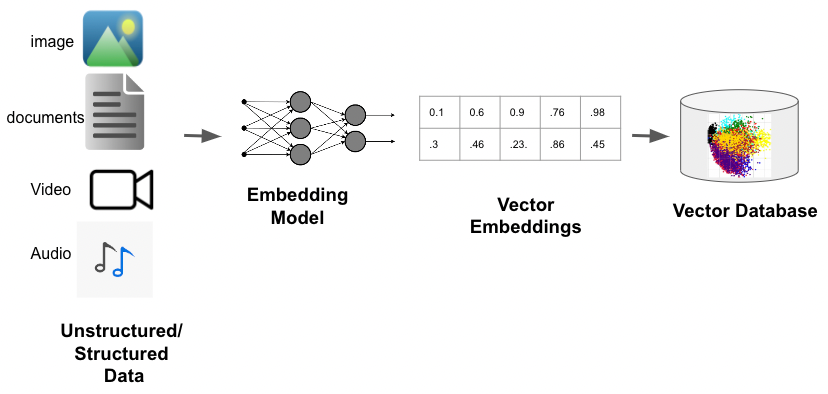

In [ ]:
## 1-qadam: Ma’lumot tayyorlash

import numpy as np

X_train = np.array([
    [0.1, 0.2, 0.3],   # Farhod
    [0.12, 0.22, 0.28],
    [0.8, 0.7, 0.6],   # Ali
    [0.82, 0.72, 0.65]
])

y_train = np.array([
    "Farhod",
    "Farhod",
    "Ali",
    "Ali"
])

In [ ]:
# 2-qadam: KNN modelini o‘qitish
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

**Bu yerda nima bo‘ladi?**


*   Model hech narsa o‘rganmaydi
*   Faqat ma’lumotni saqlab qo‘yadi
*   Shuning uchun KNN → lazy algorithm
*   Shuning uchun KNN → lazy algorithm


**3-qadam: Yangi yuzni aniqlash**



In [ ]:
yangi_yuz_vectori = np.array([[0.11, 0.21, 0.29]])

prediction = knn.predict(yangi_yuz_vectori)
print("Natija:", prediction[0])

Natija: Farhod


### **4. KNN qanday ishlaydi?**

Eng ko‘p ishlatiladigan formula:

*d=(x1​−x2​)2+(y1​−y2​)2+...*

*   **Farhodgacha masofa = 0.03**
*   Aligacha masofa    = 0.85






## **5. Real hayotdagi face recognition**

In [ ]:
!pip install face_recognition opencv-python scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 MB 6.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for face-recognition-models: filename=face_recognition_models-0.3.0-py2.py3-none-any.whl size=100566166 sha256=dae0bec1374e3e6ffc943319f4cb93060db8ee2c703f567993f798a863ba3102
  Stored in directory: /root/.cache/pip/wheels/8f/47/c8/f44c5aebb7507f7c8a2c0bd23151d732d0f0bd6884ad4ac635
Successfully built face-recognition-models


In [ ]:
import face_recognition

image = face_recognition.load_image_file("/content/000002.jpg")

encoding = face_recognition.face_encodings(image)[0]

In [ ]:
known_encodings = []
known_names = []

# Farhod
img1 = face_recognition.load_image_file("/content/000002.jpg")
img2 = face_recognition.load_image_file("/content/000016.jpg")

known_encodings.append(face_recognition.face_encodings(img1)[0])
known_names.append("Farhod")

known_encodings.append(face_recognition.face_encodings(img2)[0])
known_names.append("Farhod")

# Ali
img3 = face_recognition.load_image_file("/content/000002.jpg")
known_encodings.append(face_recognition.face_encodings(img3)[0])
known_names.append("Ali")

## KNN o‘qitish

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(known_encodings, known_names)

KNeighborsClassifier(n_neighbors=3)

### dataset: https://drive.google.com/drive/folders/15yn29YUUHKvWXu4xadIwBMVzejssJVh3?usp=sharing

In [ ]:
import os
import gdown

# Install gdown if not already installed
!pip install -q gdown

# Replace with your Google Drive folder link
google_drive_link = "https://drive.google.com/drive/folders/15yn29YUUHKvWXu4xadIwBMVzejssJVh3?usp=sharing"

# Extract folder ID from the link
try:
    folder_id = google_drive_link.split('/')[-1].split('?')[0]
    print(f"Extracted Folder ID: {folder_id}")
except IndexError:
    print("Error: Could not extract folder ID from the provided link.")
    folder_id = None

if folder_id:
    output_folder_name = "downloaded_folder" # Name for the local folder
    if not os.path.exists(output_folder_name):
        os.makedirs(output_folder_name)
        print(f"Created directory: {output_folder_name}")

    try:
        print(f"Downloading folder '{folder_id}' to '{output_folder_name}'...")
        gdown.download_folder(id=folder_id, output=output_folder_name, quiet=False, use_cookies=False)
        print("Download complete!")
    except Exception as e:
        print(f"An error occurred during download: {e}")
        print("Please ensure the folder link is correct and the folder is publicly shared or shared with 'Anyone with the link'.")
else:
    print("Cannot proceed with download without a valid folder ID.")

Extracted Folder ID: 15yn29YUUHKvWXu4xadIwBMVzejssJVh3
Created directory: downloaded_folder


Retrieving folder contents


Retrieving folder 19DUOIPwxgQ_gV7_8C4HSkYvYiYLm_uIr Brad
Processing file 1lYp3VZrSxtpBoJ3EhyUgo6oM_RVR2Lxn 011_270cd3ea.jpg
Processing file 10V8kP0gg4xoWZM0fnoNy2jIN9zJJyP6N 012_8de7a736.jpg
Processing file 1959nr7vJjwM4ERJkNMSuoNUhzIo2xTHG 013_0c83ca91.jpg
Processing file 1-icSaMEHyPZnYL8UNvOFnGvjyhsWEXLW 014_871b0d80.jpg
Processing file 1Ai2-OlmPYhTGOqGksLOZ_dVLr2lACWp4 015_82889ec9.jpg
Processing file 1ISVNSWs9Id0Aszl-vOhPF9BQuH6voWIz 016_8bb23f7e.jpg
Processing file 1C-YPAfRMyHkGbBxf-FUBbCoH3CBXes2s 017_4748675b.jpg
Processing file 1c0imEh9BjnTEdAVfe7dxMS5f9_BLJTY6 018_136dbb40.jpg
Processing file 1tY2KAG5Z5ytnsSiDM_sr-s3hpD2x4M7f 019_ddcd5687.jpg
Processing file 1DTkTqR3wFPaispCF6FG28NSsSq6xS_aH 020_45c8d790.jpg
Retrieving folder 1ERLUJ0DN7Kjmsyfd84DQouYlp5rDSnen Jonny
Processing file 1TK70YVK0toGcxDALwIaox2AjOsDaJXZI 001_2288a4f6.jpg
Processing file 1pH4l6WRkmze45t1zYNxaa0Nfn1Aiqrrv 002_331d0423.jpg
Processing file 1UVTN6A5Hz7MmQVTGZwigXlh9sihuHdVU 003_64926b97.jpg
Processing fil

Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1lYp3VZrSxtpBoJ3EhyUgo6oM_RVR2Lxn
To: /content/downloaded_folder/Brad/011_270cd3ea.jpg
100%|██████████| 5.26k/5.26k [00:00<00:00, 10.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=10V8kP0gg4xoWZM0fnoNy2jIN9zJJyP6N
To: /content/downloaded_folder/Brad/012_8de7a736.jpg
100%|██████████| 23.2k/23.2k [00:00<00:00, 33.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1959nr7vJjwM4ERJkNMSuoNUhzIo2xTHG
To: /content/downloaded_folder/Brad/013_0c83ca91.jpg
100%|██████████| 30.4k/30.4k [00:00<00:00, 42.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1-icSaMEHyPZnYL8UNvOFnGvjyhsWEXLW
To: /content/downloaded_folder/Brad/014_871b0d80.jpg
100%|██████████| 5.37k/5.37k [00:00<00:00, 12.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Ai2-OlmPYhTGOqGksLOZ_dVLr2lACWp4
To: /content/downloaded_folder/Brad/015_8

Download complete!



Download completed


### Dataset bilan KNN modelini o'qitib ko'ramiz

In [ ]:
import os
import face_recognition
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

# Dataset path
dataset_path = "/content/downloaded_folder"

known_encodings = []
known_labels = []

# 1. Papkalarni o‘qish
for person_name in os.listdir(dataset_path):
    person_folder = os.path.join(dataset_path, person_name)

    if not os.path.isdir(person_folder):
        continue

    print(f"[INFO] Processing {person_name}...")

    # 2. Har bir rasmni o‘qish
    for image_name in os.listdir(person_folder):
        image_path = os.path.join(person_folder, image_name)

        try:
            image = face_recognition.load_image_file(image_path)
            encodings = face_recognition.face_encodings(image)

            # Agar yuz topilsa
            if len(encodings) > 0:
                known_encodings.append(encodings[0])
                known_labels.append(person_name)
            else:
                print(f"Yuz topilmadi: {image_path}")

        except Exception as e:
            print(f"[ERROR] {image_path} -> {e}")

print("[INFO] Dataset tayyor!")

# 3. KNN model
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(known_encodings, known_labels)

print("[INFO] Model train qilindi!")

[INFO] Processing Jonny...
[INFO] Processing Brad...
[INFO] Dataset tayyor!
[INFO] Model train qilindi!


### O'qigan modelni test qilib ko'ramiz

In [ ]:
def predict_image(image_path, knn, threshold=0.5):
    image = face_recognition.load_image_file(image_path)
    encodings = face_recognition.face_encodings(image)

    if len(encodings) == 0:
        return "No face detected"

    encoding = encodings[0]

    distances, _ = knn.kneighbors([encoding])

    if distances[0][0] > threshold:
        return "Unknown"

    return knn.predict([encoding])[0]


# Test
result = predict_image("/content/065_34848907.jpg", knn)
print("Natija:", result)

Natija: Brad


In [ ]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

# Example: stored embeddings (pretend extracted from images)
X_train = [
    [0.12, 0.45, 0.33],  # Person A
    [0.11, 0.44, 0.30],
    [0.80, 0.10, 0.20],  # Person B
    [0.82, 0.12, 0.25]
]

y_train = ["Person_A", "Person_A", "Person_B", "Person_B"]

# Train KNN
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# New face embedding
new_face = [[0.10, 0.43, 0.31]]

prediction = knn.predict(new_face)
print("Tanish - bu :", prediction[0])

Recognized as: Person_A


In [ ]:
# ================================
# 1: Kutibxonalarni chaqirib olamiz
# ================================
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns


Malumot shakli: (1797, 64)
Belgilanganlar: (1797,)


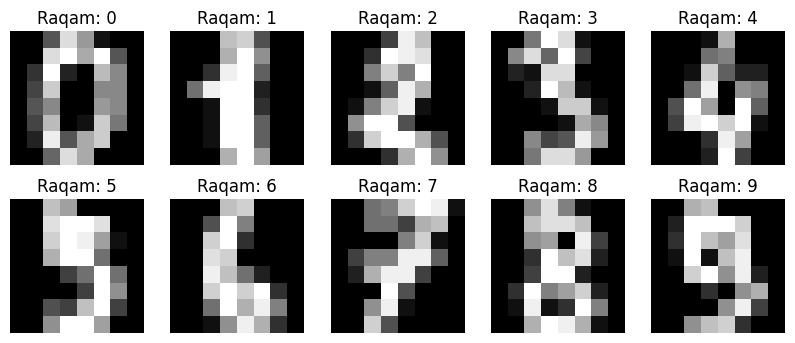

In [ ]:
# ================================
# 2: Rasmli malumotlarni yuklab olamiz
# ================================
digits = datasets.load_digits()
X = digits.data    # 8x8=64, yani har bir rasmni son ko'rinishida ibodalab olamiz
y = digits.target  # va bu sonlar qaysi raqamni DNK si ekanini bilgilab olamiz

print("Malumot shakli:", X.shape)
print("Belgilanganlar:", y.shape)

# Rasmli malumotlarni ifodalash uchun code
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(digits.images[i], cmap='gray')
    plt.title(f"Raqam: {digits.target[i]}")
    plt.axis('off')
plt.show()


In [ ]:
# ================================
# 3: Train/Test ga ajratib olamiz
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# RAqamlarni xususiyatlarini qiymatlab olamiz
# agarda biz insonni tashqi ko'rinishini klassifikatsiya qilayotgan bo'lsak:
    # Bo'yi: 150-200
    # Vazni: 50-120
    # deb belgilasak. Bunda algoritm Insonni bo'yi muhimroq, chunki qiymati kattaroq deb hisoblab qolishi mumkin.
# Shuning uchun raqamlarni xususiyatlarini qiymatlab olamiz.

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)   #  k=5
knn.fit(X_train, y_train)                   # Train on training data
print("✅ K-NN Modeli o'rganishni tugatdi.")



✅ K-NN Modeli o'rganishni tugatdi.


ANIQLILIGI: 0.9703703703703703

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        54
           1       0.95      1.00      0.97        55
           2       0.96      1.00      0.98        53
           3       0.98      0.98      0.98        55
           4       0.98      0.93      0.95        54
           5       0.98      0.96      0.97        55
           6       0.98      0.98      0.98        54
           7       0.93      0.98      0.95        54
           8       0.98      0.92      0.95        52
           9       0.96      0.94      0.95        54

    accuracy                           0.97       540
   macro avg       0.97      0.97      0.97       540
weighted avg       0.97      0.97      0.97       540



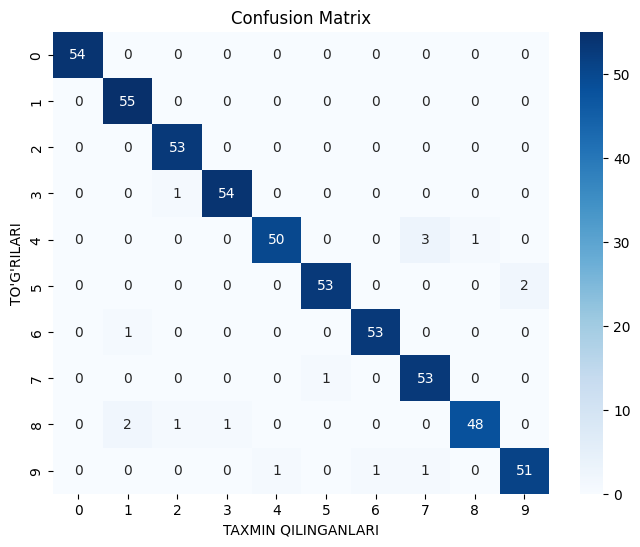

In [ ]:
# TEST QILISH
# ================================
y_pred = knn.predict(X_test)

print("ANIQLILIGI:", accuracy_score(y_test, y_pred))

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap="Blues")
plt.xlabel("TAXMIN QILINGANLARI")
plt.ylabel("TO'G'RILARI")
plt.title("Confusion Matrix")
plt.show()


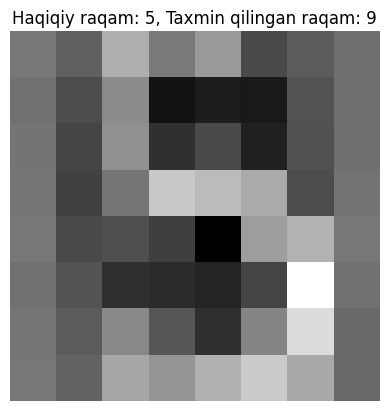

In [ ]:
# 4: K-NN da turli raqamlarni klassifikatsiya qilish testi
# ================================
import numpy as np
rand_index = np.random.randint(0, len(X_test))

# Test qilinayotgan raqamni ifodalash
plt.imshow(X_test[rand_index].reshape(8, 8), cmap='gray')
plt.title(f"Haqiqiy raqam: {y_test[rand_index]}, Taxmin qilingan raqam: {knn.predict([X_test[rand_index]])[0]}")
plt.axis('off')
plt.show()

## **Decision Tree** algoritmi bo'yicha klassifikatsiyalash


In [ ]:
# DECISION TREE algoritmi

# 1: Kutobxonalarni chaqirish
# =========================
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

In [ ]:
# 2: Dataset ni yuklash (raqamlar: 0-9,  8x8 pixelli)
# ===================================================
digits = load_digits()
X, y = digits.data, digits.target
# X = raqamni xususiyatlari (pixelda ifodalangan),
# y = belgilab olingan raqamlar (0-9)

print("Dataset shakli:", X.shape)   # (1797, 64) -> 1797 ta rasm, har biri 64 pixelli
print('Belgilanga sinflar, yani "y" da ifodalangan:',
      set(y))




# 3: Dataset ni training and testing qismlarga bo'lib olish
# =======================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


Dataset shakli: (1797, 64)
Belgilanga sinflar, yani "y" da ifodalangan: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)}


In [ ]:
# 4: Decision Tree algoritmini o'qitish boshlanishi
# ==============================
dt = DecisionTreeClassifier(criterion="gini", max_depth=10, random_state=42)
dt.fit(X_train, y_train)





DecisionTreeClassifier(max_depth=10, random_state=42)

In [ ]:
# 5: O'qtilgan Modelni aniqlilik darajasi
# =======================
y_pred = dt.predict(X_test)
print("Modelni aniqliligi:", accuracy_score(y_test, y_pred))

Modelni aniqliligi: 0.85


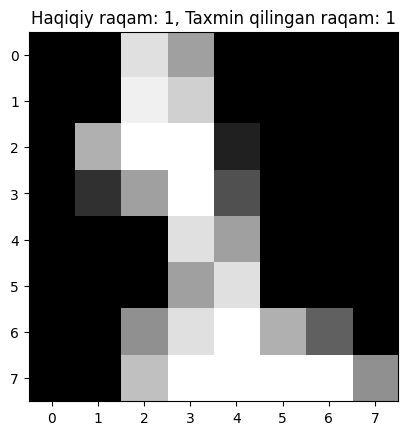

In [ ]:
# 6: Ramdom rasm bilan test qilish
# ================================
import numpy as np
i = np.random.randint(0, len(X_test))
plt.imshow(X_test[i].reshape(8, 8), cmap="gray")
plt.title(f"Haqiqiy raqam: {y_test[i]}, Taxmin qilingan raqam: {dt.predict([X_test[i]])[0]}")
plt.axis("on")
plt.show()


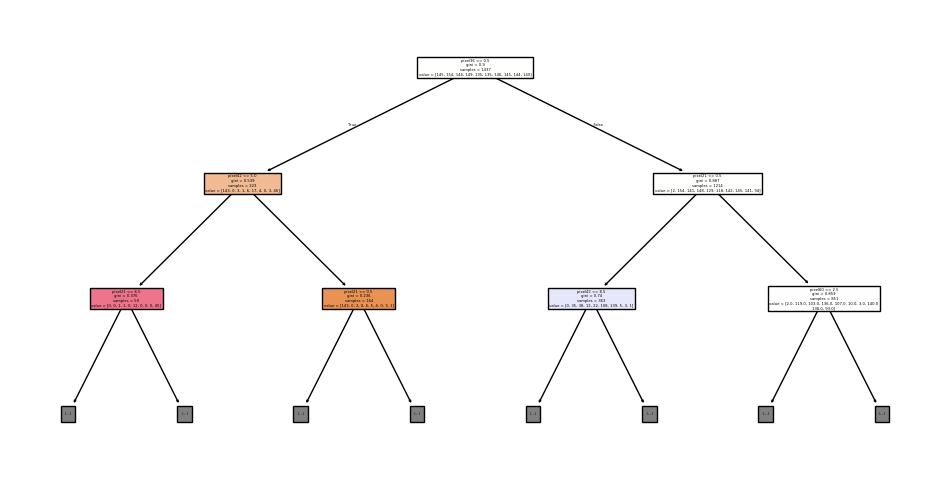

In [ ]:
plt.figure(figsize=(12, 6))
plot_tree(dt, filled=True, max_depth=2, feature_names=[f"pixel{i}" for i in range(64)])
plt.show()

## **Random forest:** algoritmi bo'yicha klassifikatsiyalash

In [ ]:
# ================================
# 1. Kutubxonalarni chaqirish
# ================================
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# ================================
# 2. DAtaset yuklash
# ================================
digits = datasets.load_digits()
X, y = digits.data, digits.target

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# ================================
# 3. RF ni train qilish
# ================================
rf = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42)
rf.fit(X_train, y_train)
print("✅ RF modeli qurildi.")


✅ RF modeli qurildi.


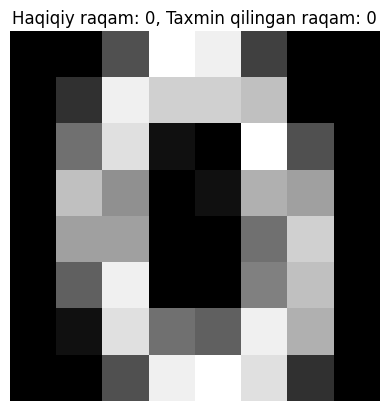

In [ ]:
# ================================
# 4. Test on a random digit
# ================================
rand_index = np.random.randint(0, len(X_test))
plt.imshow(X_test[rand_index].reshape(8, 8), cmap='gray')

pred = rf.predict([X_test[rand_index]])[0]
plt.title(f"Haqiqiy raqam: {y_test[rand_index]}, Taxmin qilingan raqam: {pred}")
plt.axis('off')
plt.show()

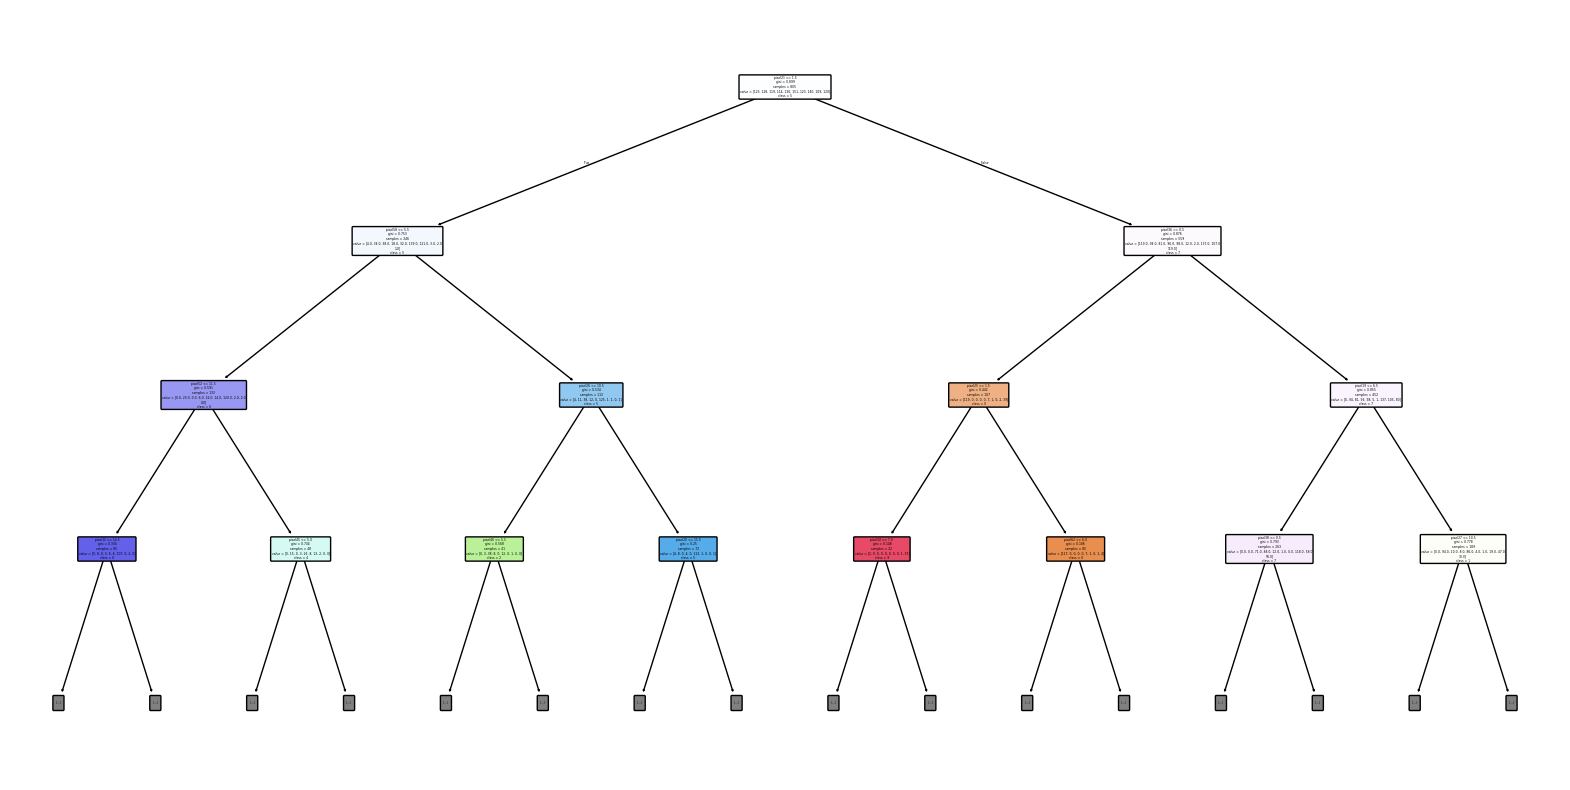

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
plot_tree(
    rf.estimators_[0],
    filled=True,
    max_depth=3,
    feature_names=[f"pixel{i}" for i in range(64)],
    class_names=[str(i) for i in range(10)],
    rounded=True
)
plt.show()


## **SVM:** algoritmi bo'yicha klassifikatsiyalash

1.   List item
2.   List item



In [ ]:
# Kerakli kutubxonalarni chaqirib olamiz
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# Malumotlarni yuklab olamiz
digits = datasets.load_digits()  # Raqamlar misolida
X = digits.data
y = digits.target

# Faqat 0 va 1 sonlari misolida SVM ni ishlatib ko'ramiz
X = X[(y == 0) | (y == 1)]
y = y[(y == 0) | (y == 1)]

# Malumotni taqsimlash
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Normallashtirish
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# SVM algoritmi yordamida model qurishni boshlash

model = SVC(kernel='rbf', C=1.0, gamma='scale')
model.fit(X_train, y_train)

SVC()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[56  0]
 [ 0 52]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        56
           1       1.00      1.00      1.00        52

    accuracy                           1.00       108
   macro avg       1.00      1.00      1.00       108
weighted avg       1.00      1.00      1.00       108



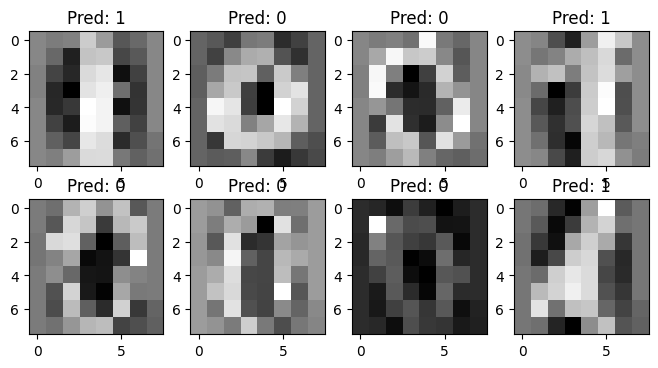

In [ ]:
plt.figure(figsize=(8,4))
for index, (image, label) in enumerate(zip(X_test[0:8], y_pred[0:8])):
    plt.subplot(2, 4, index + 1)
    plt.imshow(image.reshape(8,8), cmap=plt.cm.gray)
    plt.title(f'Pred: {label}')
plt.show()

## **Logistic regression:** algoritmi bo'yicha klassifikatsiyalash

In [ ]:
# ================================
# 1. Imports
# ================================
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import numpy as np

# ================================
# 2. Load digits dataset
# ================================
digits = datasets.load_digits()
X, y = digits.data, digits.target

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ================================
# 3. Train Logistic Regression
# ================================
logreg = LogisticRegression(max_iter=1000)  # Increase iterations to converge
logreg.fit(X_train, y_train)
print("✅ Logistic Regression model trained.")



✅ Logistic Regression model trained.


Aniqlik (Accuracy): 80.00%
Klassifikatsiya hisoboti:
              precision    recall  f1-score   support

           0       1.00      0.93      0.96        54
           1       0.44      1.00      0.61        55
           2       0.98      0.77      0.86        53
           3       0.98      0.80      0.88        55
           4       1.00      0.31      0.48        54
           5       1.00      0.84      0.91        55
           6       0.92      0.91      0.92        54
           7       1.00      0.70      0.83        54
           8       0.88      0.73      0.80        52
           9       0.68      1.00      0.81        54

    accuracy                           0.80       540
   macro avg       0.89      0.80      0.81       540
weighted avg       0.89      0.80      0.80       540



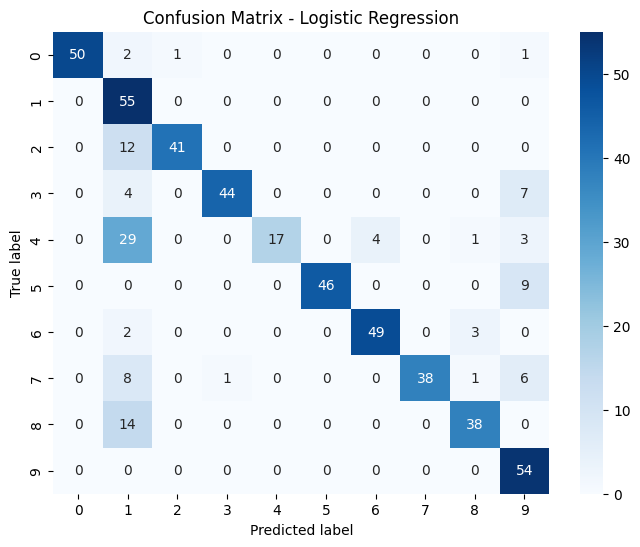

In [ ]:
# ================================
# 6: Modelni test qilish
# ================================
y_pred = logreg.predict(X_test)

# Natijalarni baholash
acc = accuracy_score(y_test, y_pred)
print(f"Aniqlik (Accuracy): {acc*100:.2f}%")

print("Klassifikatsiya hisoboti:")
print(classification_report(y_test, y_pred))

# ================================
# 7: Confusion matritsasini chizish
# ================================
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap="Blues", fmt="d")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()


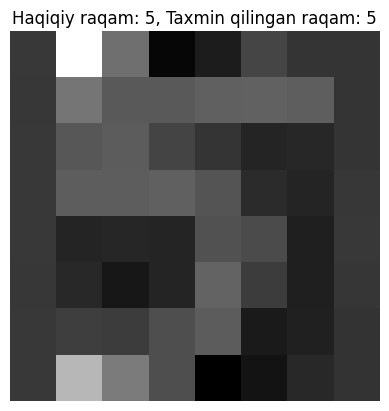

In [ ]:
# Random test
rand_index = np.random.randint(0, len(X_test))

# Test image
plt.imshow(X_test[rand_index].reshape(8, 8), cmap='gray')

# Prediction
pred = logreg.predict([X_test[rand_index]])[0]

plt.title(f"Haqiqiy raqam: {y_test[rand_index]}, Taxmin qilingan raqam: {pred}")
plt.axis('off')
plt.show()


## **Naive Bayes** algoritmi

Dataset shape: (1797, 64)
Labels shape: (1797,)


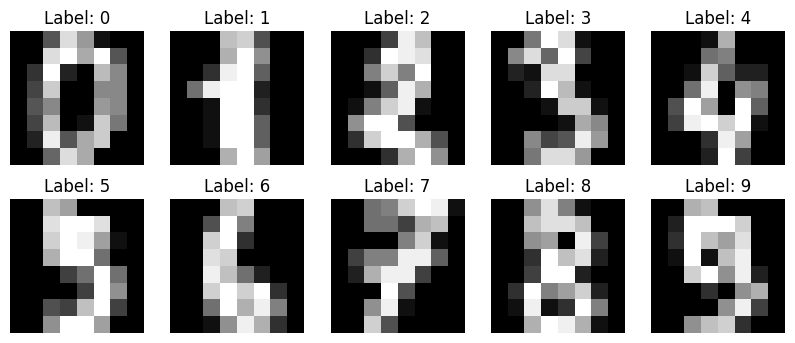

✅ Naive Bayes modeli qurildi.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

digits = datasets.load_digits()
X = digits.data
y = digits.target

print("Dataset shape:", X.shape)  # (n_samples, 64)
print("Labels shape:", y.shape)

# ===========================
plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(digits.images[i], cmap='gray')
    plt.title(f"Label: {digits.target[i]}")
    plt.axis('off')
plt.show()

#=============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# ============================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#========================

nb = GaussianNB()
nb.fit(X_train, y_train)
print("✅ Naive Bayes modeli qurildi.")




Accuracy: 77.22%

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.91      0.94        54
           1       0.53      0.84      0.65        55
           2       0.86      0.57      0.68        53
           3       1.00      0.44      0.61        55
           4       0.97      0.69      0.80        54
           5       0.93      0.91      0.92        55
           6       0.93      0.98      0.95        54
           7       0.75      0.98      0.85        54
           8       0.46      0.73      0.56        52
           9       0.88      0.69      0.77        54

    accuracy                           0.77       540
   macro avg       0.83      0.77      0.77       540
weighted avg       0.83      0.77      0.77       540



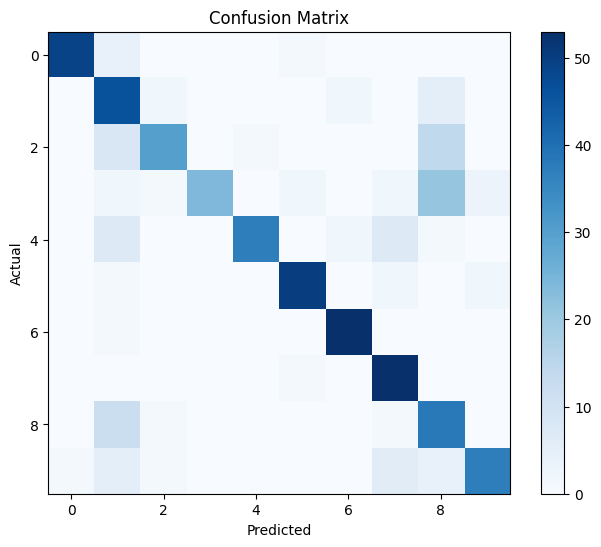

In [ ]:

y_pred = nb.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc*100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

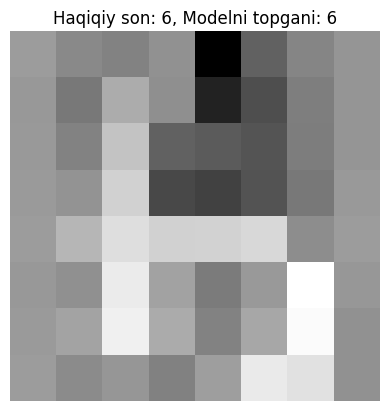

In [ ]:
rand_idx = np.random.randint(0, len(X_test))
plt.imshow(X_test[rand_idx].reshape(8,8), cmap='gray')
plt.title(f"Haqiqiy son: {y_test[rand_idx]}, Modelni topgani: {nb.predict([X_test[rand_idx]])[0]}")
plt.axis('off')
plt.show()

## Unsupervised learning K-means algoritm misolida


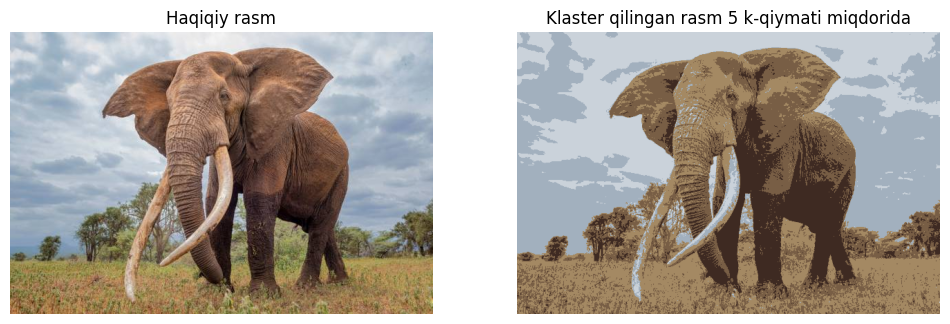

In [ ]:
import cv2
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


image = cv2.imread('/content/is.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

pixels = image.reshape(-1, 3)

k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(pixels)

new_colors = kmeans.cluster_centers_[kmeans.labels_]
quantized_image = new_colors.reshape(image.shape).astype(np.uint8)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Haqiqiy rasm")
plt.imshow(image)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title(f"Klaster qilingan rasm {k} k-qiymati miqdorida")
plt.imshow(quantized_image)
plt.axis('off')

plt.show()


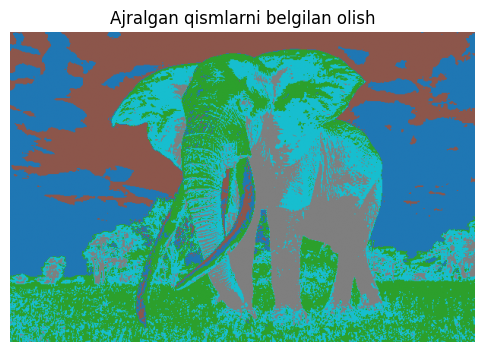

In [ ]:
labels = kmeans.labels_.reshape(image.shape[:2])

plt.figure(figsize=(6, 6))
plt.title("Ajralgan qismlarni belgilan olish")
plt.imshow(labels, cmap='tab10')
plt.axis('off')
plt.show()


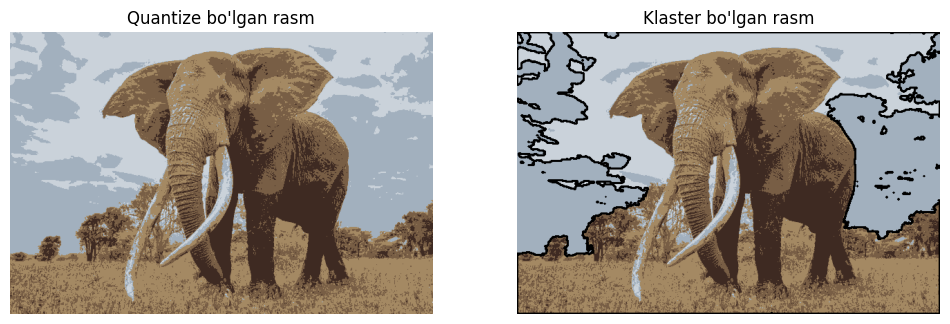

In [ ]:
# Ajralgan label qismlarni uint8 formatiga o'zgartirib, kontirlarni aniqlaymiz
label_uint8 = (labels * (255 / (labels.max()))).astype(np.uint8)

# Har bir kluster qilingan hudud bo'yicha kontorlarni topamiz
contours, _ = cv2.findContours(label_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Chizishni boshlaymiz
outlined = quantized_image.copy()
cv2.drawContours(outlined, contours, -1, (0, 0, 0), 2)  # qaysi rangda?

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Quantize bo'lgan rasm")
plt.imshow(quantized_image)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Klaster bo'lgan rasm")
plt.imshow(outlined)
plt.axis('off')
plt.show()


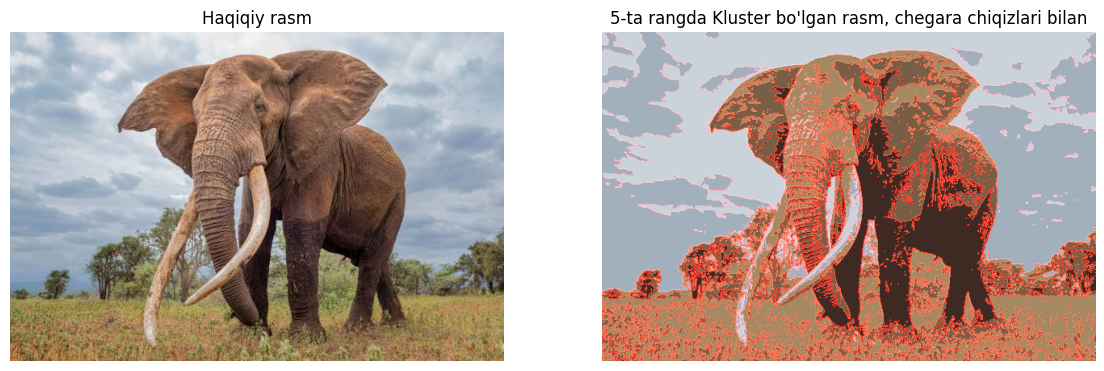

In [ ]:

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(pixels)
quantized = kmeans.cluster_centers_[labels].reshape(image.shape).astype(np.uint8)

# Labellarni 2D rasm ko'rinishiga obkelamiz

label_map = labels.reshape(image.shape[:2]).astype(np.int32)

# Klusterlar o'rtasidagi chegaralarni topamiz
edges = np.zeros_like(label_map, dtype=np.uint8)
edges[:-1, :] |= (label_map[:-1, :] != label_map[1:, :])
edges[:, :-1] |= (label_map[:, :-1] != label_map[:, 1:])

# RGB kanal shakliga o'rkazamiz
edges_colored = np.zeros_like(image)
edges_colored[edges > 0] = [255, 0, 0]

# Quantize bo'lgan rasmga qizil chiziq chizamiz
outlined = cv2.addWeighted(quantized, 1.0, edges_colored, 1.0, 0)


plt.figure(figsize=(14, 7))
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Haqiqiy rasm")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(outlined)
plt.title(f"{k}-ta rangda Kluster bo'lgan rasm, chegara chiqizlari bilan")
plt.axis("off")

plt.show()


### NLP misolida

In [ ]:
!pip install scikit-learn nltk

In [ ]:
documents = [
    "I love football",
    "Messi scored a goal",
    "Python is a programming language",
    "Machine learning is amazing",
    "Ronaldo plays football",
    "Deep learning uses neural networks"
]

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(documents)

print(X.shape)

(6, 18)


In [ ]:
# K-means algoritmini qo'llash
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=2,
    random_state=42
)

kmeans.fit(X)

KMeans(n_clusters=2, random_state=42)

In [ ]:
for doc, label in zip(documents, kmeans.labels_):
    print(f"Cluster {label}: {doc}")

Cluster 1: I love football
Cluster 0: Messi scored a goal
Cluster 0: Python is a programming language
Cluster 0: Machine learning is amazing
Cluster 1: Ronaldo plays football
Cluster 0: Deep learning uses neural networks


In [ ]:
news = [
    "Stock market crashes today",
    "New AI model released",
    "Football world cup starts",
    "NVIDIA releases new GPU",
    "Messi wins another trophy",
    "Researchers create robot"
]

In [ ]:
X = vectorizer.fit_transform(news)

In [ ]:
kmeans = KMeans(n_clusters=3)

labels = kmeans.fit_predict(X)

In [ ]:
for text, label in zip(news, labels):
    print(label, text)

0 Stock market crashes today
0 New AI model released
0 Football world cup starts
0 NVIDIA releases new GPU
2 Messi wins another trophy
1 Researchers create robot


## GAN misolida

In [ ]:
import time
import numpy as np
import torch
import torch.nn.functional as F
from torchvision import datasets
from torchvision import transforms
import torch.nn as nn
from torch.utils.data import DataLoader


if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True

In [ ]:
##########################
### SETTINGS
##########################

device = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")

# Hyperparametrlar
random_seed = 123
generator_learning_rate = 0.001
discriminator_learning_rate = 0.001
NUM_EPOCHS = 100
BATCH_SIZE = 128
LATENT_DIM = 75
IMG_SHAPE = (1, 28, 28)
IMG_SIZE = 1
for x in IMG_SHAPE:
    IMG_SIZE *= x



##########################
### MNIST DATASET
##########################

train_dataset = datasets.MNIST(root='data',
                               train=True,
                               transform=transforms.ToTensor(),
                               download=True)

test_dataset = datasets.MNIST(root='data',
                              train=False,
                              transform=transforms.ToTensor())


train_loader = DataLoader(dataset=train_dataset,
                          batch_size=BATCH_SIZE,
                          shuffle=True)

test_loader = DataLoader(dataset=test_dataset,
                         batch_size=BATCH_SIZE,
                         shuffle=False)

# Datasetni tekshirish
for images, labels in train_loader:
    print('Image batch dimensions:', images.shape)
    print('Image label dimensions:', labels.shape)
    break

100%|██████████| 9.91M/9.91M [00:00<00:00, 60.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.72MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.0MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.53MB/s]

Image batch dimensions: torch.Size([128, 1, 28, 28])
Image label dimensions: torch.Size([128])


In [ ]:
##########################
### MODEL
##########################


class GAN(torch.nn.Module):

    def __init__(self):
        super(GAN, self).__init__()


        self.generator = nn.Sequential(
            nn.Linear(LATENT_DIM, 128),
            nn.LeakyReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(128, IMG_SIZE),
            nn.Tanh()
        )

        self.discriminator = nn.Sequential(
            nn.Linear(IMG_SIZE, 128),
            nn.LeakyReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )


    def generator_forward(self, z):
        img = self.generator(z)
        return img

    def discriminator_forward(self, img):
        pred = model.discriminator(img)
        return pred.view(-1)

In [ ]:
torch.manual_seed(random_seed)

model = GAN()
model = model.to(device)

optim_gener = torch.optim.Adam(model.generator.parameters(), lr=generator_learning_rate)
optim_discr = torch.optim.Adam(model.discriminator.parameters(), lr=discriminator_learning_rate)

In [ ]:
start_time = time.time()

NUM_EPOCHS = 10

discr_costs = []
gener_costs = []
for epoch in range(NUM_EPOCHS):
    model = model.train()
    for batch_idx, (features, targets) in enumerate(train_loader):



        features = (features - 0.5)*2.
        features = features.view(-1, IMG_SIZE).to(device)
        targets = targets.to(device)

        valid = torch.ones(targets.size(0)).float().to(device)
        fake = torch.zeros(targets.size(0)).float().to(device)

        # --------------------------
        # Generator ni o'qitish
        # --------------------------

        # Yangirasmlar yashash
        z = torch.zeros((targets.size(0), LATENT_DIM)).uniform_(-1.0, 1.0).to(device)
        generated_features = model.generator_forward(z)

        # Ajratish
        discr_pred = model.discriminator_forward(generated_features)

        gener_loss = F.binary_cross_entropy(discr_pred, valid)

        optim_gener.zero_grad()
        gener_loss.backward()
        optim_gener.step()

        # --------------------------
        # Ajratuvchini o'qitish
        # --------------------------

        discr_pred_real = model.discriminator_forward(features.view(-1, IMG_SIZE))
        real_loss = F.binary_cross_entropy(discr_pred_real, valid)

        discr_pred_fake = model.discriminator_forward(generated_features.detach())
        fake_loss = F.binary_cross_entropy(discr_pred_fake, fake)

        discr_loss = 0.5*(real_loss + fake_loss)

        optim_discr.zero_grad()
        discr_loss.backward()
        optim_discr.step()

        discr_costs.append(discr_loss)
        gener_costs.append(gener_loss)


        # Log qilish
        if not batch_idx % 10:
            print ('Epoch: %03d/%03d | Batch %03d/%03d | Gen/Dis Loss: %.4f/%.4f'
                   %(epoch+1, NUM_EPOCHS, batch_idx,
                     len(train_loader), gener_loss, discr_loss))

    print('Time elapsed: %.2f min' % ((time.time() - start_time)/60))

print('Total Training Time: %.2f min' % ((time.time() - start_time)/60))

Epoch: 001/010 | Batch 000/469 | Gen/Dis Loss: 1.1713/0.3617
Epoch: 001/010 | Batch 010/469 | Gen/Dis Loss: 1.1606/0.4616
Epoch: 001/010 | Batch 020/469 | Gen/Dis Loss: 1.3128/0.3557
Epoch: 001/010 | Batch 030/469 | Gen/Dis Loss: 1.4465/0.3237
Epoch: 001/010 | Batch 040/469 | Gen/Dis Loss: 1.1241/0.2950
Epoch: 001/010 | Batch 050/469 | Gen/Dis Loss: 1.3582/0.3613
Epoch: 001/010 | Batch 060/469 | Gen/Dis Loss: 1.2787/0.3860
Epoch: 001/010 | Batch 070/469 | Gen/Dis Loss: 2.2506/0.1842
Epoch: 001/010 | Batch 080/469 | Gen/Dis Loss: 1.2986/0.3186
Epoch: 001/010 | Batch 090/469 | Gen/Dis Loss: 2.2787/0.2881
Epoch: 001/010 | Batch 100/469 | Gen/Dis Loss: 1.9335/0.3109
Epoch: 001/010 | Batch 110/469 | Gen/Dis Loss: 1.2099/0.4493
Epoch: 001/010 | Batch 120/469 | Gen/Dis Loss: 0.9272/0.4643
Epoch: 001/010 | Batch 130/469 | Gen/Dis Loss: 1.6440/0.2508
Epoch: 001/010 | Batch 140/469 | Gen/Dis Loss: 1.9850/0.2448
Epoch: 001/010 | Batch 150/469 | Gen/Dis Loss: 1.5977/0.2780
Epoch: 001/010 | Batch 1

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

/tmp/ipython-input-2861435337.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(newlabel[::10])


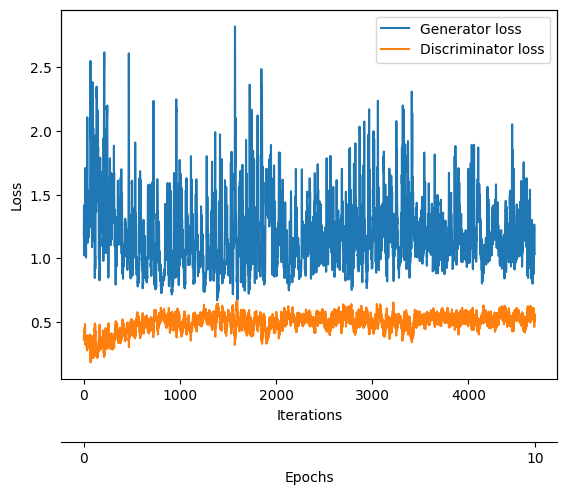

In [ ]:
ax1 = plt.subplot(1, 1, 1)
ax1.plot(range(len(gener_costs)), [cost.detach().numpy() for cost in gener_costs], label='Generator loss')
ax1.plot(range(len(discr_costs)), [cost.detach().numpy() for cost in discr_costs], label='Discriminator loss')
ax1.set_xlabel('Iterations')
ax1.set_ylabel('Loss')
ax1.legend()

###################

ax2 = ax1.twiny()
newlabel = list(range(NUM_EPOCHS+1))
iter_per_epoch = len(train_loader)
newpos = [e*iter_per_epoch for e in newlabel]

ax2.set_xticklabels(newlabel[::10])
ax2.set_xticks(newpos[::10])

ax2.xaxis.set_ticks_position('bottom')
ax2.xaxis.set_label_position('bottom')
ax2.spines['bottom'].set_position(('outward', 45))
ax2.set_xlabel('Epochs')
ax2.set_xlim(ax1.get_xlim())
###################

plt.show()

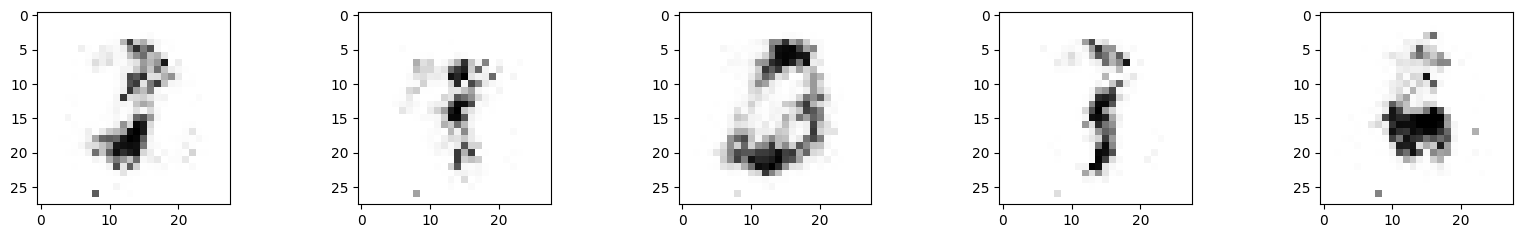

In [ ]:
##########################
### VISUALIZATION
##########################


model.eval()
# Yangi rasmlar yasash
z = torch.zeros((5, LATENT_DIM)).uniform_(-1.0, 1.0).to(device)
generated_features = model.generator_forward(z)
imgs = generated_features.view(-1, 28, 28)

fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(20, 2.5))


for i, ax in enumerate(axes):
    axes[i].imshow(imgs[i].to(torch.device('cpu')).detach(), cmap='binary')

## Yuzdagi nuqtalar bilan ishlash

> Face landmarks

> Mediapipe - 468 nuqtani yuzda joylashuvi

> [link text](https://mediapipe.readthedocs.io/en/latest/solutions/face_mesh.html)







In [ ]:
!pip install mediapipe opencv-python numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.1 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of opencv-contrib-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 MB 12.3 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
  Attempting uninstall: numpy
    Found existing ins

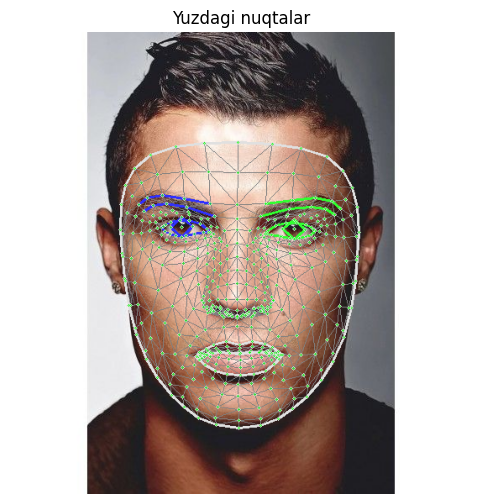

In [ ]:
# ======================================
# MEDIAPIPE - yuzdagi nuqtalarni topish
# ======================================

import cv2
import mediapipe as mp
from google.colab import files
import matplotlib.pyplot as plt

image_path = '/content/c.jpg'

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Mediapipe ni ishga tushirish
mp_face_mesh = mp.solutions.face_mesh
mp_drawing = mp.solutions.drawing_utils
mp_styles = mp.solutions.drawing_styles

with mp_face_mesh.FaceMesh(
    static_image_mode=True,
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.5
) as face_mesh:


    results = face_mesh.process(image)

    if not results.multi_face_landmarks:
        print("Nuqtalar yo'q")
    else:

        # Nuqtalarni chiqiz boshlandi
        annotated = image.copy()
        for face_landmarks in results.multi_face_landmarks:


            mp_drawing.draw_landmarks(
                image=annotated,
                landmark_list=face_landmarks,
                connections=mp_face_mesh.FACEMESH_TESSELATION,
                landmark_drawing_spec=None,
                connection_drawing_spec=mp_styles.get_default_face_mesh_tesselation_style()
            )

            mp_drawing.draw_landmarks(
                image=annotated,
                landmark_list=face_landmarks,
                connections=mp_face_mesh.FACEMESH_CONTOURS,
                landmark_drawing_spec=None,
                connection_drawing_spec=mp_styles.get_default_face_mesh_contours_style()
            )
            mp_drawing.draw_landmarks(
                image=annotated,
                landmark_list=face_landmarks,
                connections=mp_face_mesh.FACEMESH_IRISES,
                landmark_drawing_spec=None,
                connection_drawing_spec=mp_styles.get_default_face_mesh_iris_connections_style()
            )

            mp_drawing.draw_landmarks(
                image=annotated,
                landmark_list=face_landmarks,
                connections=None,
                landmark_drawing_spec=mp_drawing.DrawingSpec(color=(0,255,0), thickness=1, circle_radius=1)
            )

        plt.figure(figsize=(8, 6))
        plt.imshow(annotated)
        plt.axis('off')
        plt.title("Yuzdagi nuqtalar")
        plt.show()


 OLMA + #10 
KORDINATA O'QI:  (271, 131)


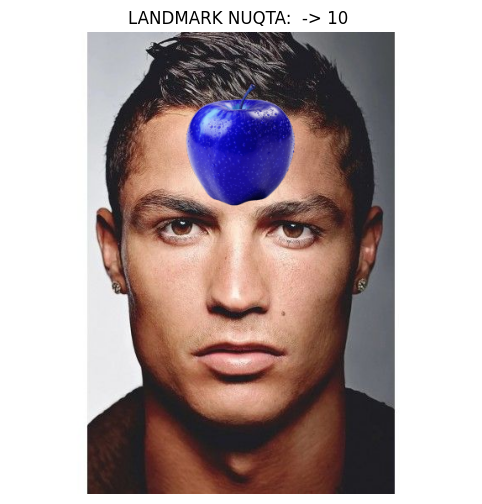

In [ ]:

face_path = "/content/c.jpg"
apple_path = "/content/olma.png"

face_img = cv2.imread(face_path)
face_img = cv2.cvtColor(face_img, cv2.COLOR_BGR2RGB)
apple_img = cv2.imread(apple_path, cv2.IMREAD_UNCHANGED)
mp_face_mesh = mp.solutions.face_mesh

with mp_face_mesh.FaceMesh(
    static_image_mode=True,
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.5
) as face_mesh:
    results = face_mesh.process(face_img)

if not results.multi_face_landmarks:
    print(" Yuz topilmadi")
else:
    annotated = face_img.copy()
    h, w, _ = annotated.shape
    face_landmarks = results.multi_face_landmarks[0]



    #  NUQTANI BELGILASH
    landmark_index = 10
    landmark = face_landmarks.landmark[landmark_index]
    x = int(landmark.x * w)
    y = int(landmark.y * h)

    print(f" OLMA + #{landmark_index} ")
    print(f"KORDINATA O'QI:  ({x}, {y})")



    # Olmani razmerini belgilash
    scale = 0.5
    apple_h, apple_w = apple_img.shape[:2]
    new_w = int(apple_w * scale)
    new_h = int(apple_h * scale)
    apple_resized = cv2.resize(apple_img, (new_w, new_h))

    x1, y1 = x - new_w // 2, y - new_h // 2
    x2, y2 = x1 + new_w, y1 + new_h

    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(w, x2)
    y2 = min(h, y2)

    roi = annotated[y1:y2, x1:x2]

    if apple_resized.shape[2] == 4:
        alpha = apple_resized[:, :, 3] / 255.0
        for c in range(3):
            roi[:, :, c] = (1 - alpha) * roi[:, :, c] + alpha * apple_resized[:, :, c]
    else:
        roi[:] = apple_resized

    annotated[y1:y2, x1:x2] = roi
    plt.figure(figsize=(8, 6))
    plt.imshow(annotated)
    plt.axis('off')
    plt.title(f"LANDMARK NUQTA:  -> {landmark_index} ")
    plt.show()


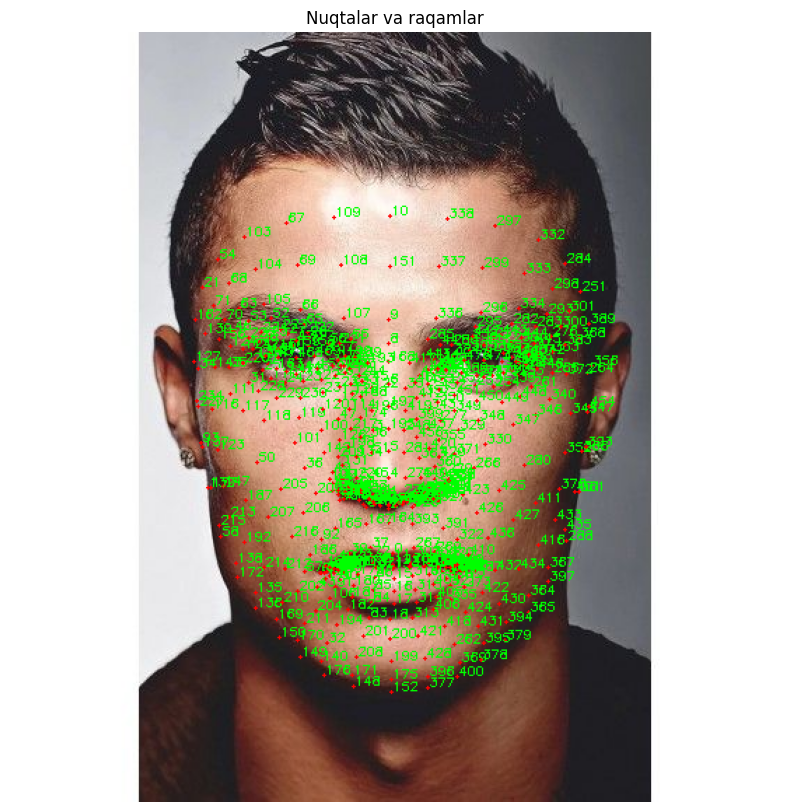

In [ ]:

face_path = "/content/c.jpg"
face_img = cv2.imread(face_path)
face_img = cv2.cvtColor(face_img, cv2.COLOR_BGR2RGB)
h, w, _ = face_img.shape

mp_face_mesh = mp.solutions.face_mesh

with mp_face_mesh.FaceMesh(
    static_image_mode=True,
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.5
) as face_mesh:
    results = face_mesh.process(face_img)

if results.multi_face_landmarks:
    face_landmarks = results.multi_face_landmarks[0]
    annotated = face_img.copy()

    for idx, landmark in enumerate(face_landmarks.landmark):
        x = int(landmark.x * w)
        y = int(landmark.y * h)

        # Mayda nuqtalarni chizish / joylashishini aniqlash
        cv2.circle(annotated, (x, y), 1, (255, 0, 0), -1)

        # Shu nuqtalarni index ini aniqlash
        cv2.putText(annotated, str(idx), (x+1, y-1),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.3, (0, 255, 0), 1)

    plt.figure(figsize=(10,10))
    plt.imshow(annotated)
    plt.axis("off")
    plt.title("Nuqtalar va raqamlar")
    plt.show()
else:
    print("Yuz topilmadi")


## **YOLO** misolida

In [ ]:
!pip install ultralytics
!pip install opencv-python matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 19.0 MB/s eta 0:00:00


## Yolo da **object detection** qilamiz


0: 640x640 1 zebra, 560.8ms
Speed: 10.7ms preprocess, 560.8ms inference, 2.4ms postprocess per image at shape (1, 3, 640, 640)


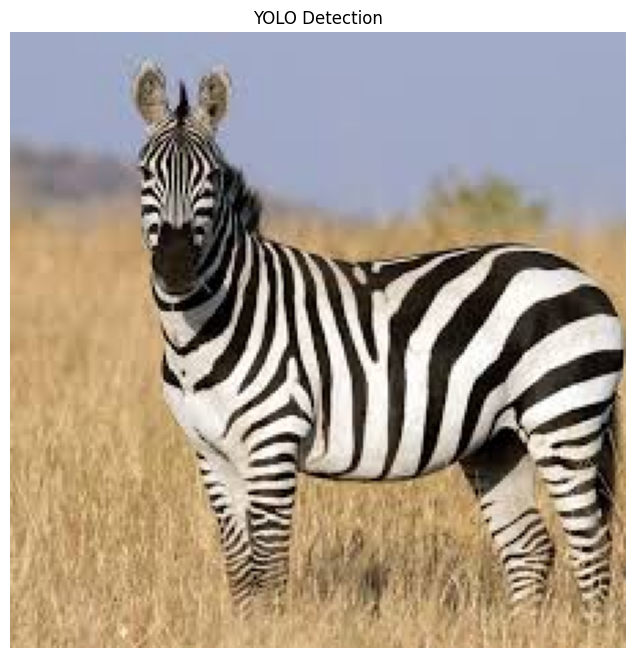

In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

model = YOLO("yolov8n.pt")

image_path = "/content/zebra.jpeg"
img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

results = model.predict(img_rgb)


# person=0, car=2, dog=16, cat=15, horse=17
target_classes = [0]  # insonlar uchun
target_classes = [2] # moshinalar uchun
target_classes = [15,16,17,18] # hayvonlar uchun
target_classes = [22]
target_classes = [23]
annotated_img = img_rgb.copy()

for r in results:
    boxes = r.boxes
    for box in boxes:
        cls_id = int(box.cls[0])
        if cls_id in target_classes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            conf = float(box.conf[0])
            label = f"{model.names[cls_id]} {conf:.2f}"

            # bounding box chizish
            cv2.rectangle(annotated_img, (x1, y1), (x2, y2), (255, 0, 0), 2)
            cv2.putText(annotated_img, label, (x1, y1-10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)


plt.figure(figsize=(12,8))
plt.imshow(annotated_img)
plt.axis("off")
plt.title("YOLO Detection")
plt.show()
